
# Grover avec modif de phase



## 1. Principe de l'algo

Soit un état marqué $|\tau\rangle$. Tout état pur peut être décomposé comme

$$
|\psi_0\rangle
=
\sin(\theta_0)|\tau\rangle
+
\cos(\theta_0)e^{i\delta}|\eta\rangle,
$$

où $|\eta\rangle$ est un état normalisé porté uniquement par les états non marqués :

$$
|\eta\rangle
=
\sum_{x\neq \tau} c_x |x\rangle.
$$

Ici, les coefficients $c_x$  sont arbitraires : leurs modules et leurs phases sont différents.

Pour utiliser la condition de phase de l'article, on choisit un unitaire $U$ tel que

$$
U|0\rangle
=
\sin(\beta)|\tau\rangle+\cos(\beta)|\eta\rangle.
$$

Le moteur est $Q =-U I_\gamma U^\dagger I_\tau$

avec

$$
I_\tau=I+(e^{i\phi}-1)|\tau\rangle\langle\tau|,
\qquad
I_\gamma=I+(e^{i\theta}-1)|0\rangle\langle 0|.
$$

La condition de phase utilisée est

$$
\tan\left(\frac{\theta}{2}\right)
\left[
\cos(2\beta)+\tan(\theta_0)\cos(\delta)\sin(2\beta)
\right]
=
\tan\left(\frac{\phi}{2}\right)
\left[
1-\tan(\theta_0)\sin(\delta)\sin(2\beta)\tan\left(\frac{\theta}{2}\right)
\right].
$$

Dans l'exemple, on absorbe les phases complexes des états non marqués dans $|\eta\rangle$


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)



## 2. Fonctions utiles


In [2]:

def hadamard(n: int) -> np.ndarray:
    """Matrice H^{otimes n}, utilisée pour Grover standard."""
    H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
    U = H.copy()
    for _ in range(n - 1):
        U = np.kron(U, H)
    return U


def unitary_with_first_column(v: np.ndarray) -> np.ndarray:
    """
    Construit un unitaire dont la première colonne est v.

    Méthode : Gram-Schmidt à partir de la base canonique.
    """
    v = np.asarray(v, dtype=complex)
    v = v / np.linalg.norm(v)
    N = len(v)

    cols = [v]
    for k in range(N):
        e = np.zeros(N, dtype=complex)
        e[k] = 1.0

        w = e.copy()
        for c in cols:
            w -= c * np.vdot(c, w)

        norm_w = np.linalg.norm(w)
        if norm_w > 1e-12:
            cols.append(w / norm_w)

        if len(cols) == N:
            break

    return np.column_stack(cols)


def phase_matching_phi(beta: float, theta0: float, delta: float, theta: float) -> float:
    """
    Calcule phi à partir de la condition de phase générale.
    """
    t = np.tan(theta / 2)
    numerator = t * (
        np.cos(2 * beta)
        + np.tan(theta0) * np.cos(delta) * np.sin(2 * beta)
    )
    denominator = (
        1
        - np.tan(theta0) * np.sin(delta) * np.sin(2 * beta) * t
    )
    phi = 2 * np.arctan2(numerator, denominator)
    return float(np.mod(phi, 2 * np.pi))


def grover_engine(n: int, marked: int, theta: float, phi: float, U: np.ndarray) -> np.ndarray:
    """
    Moteur généralisé :
        Q = - U I_gamma U^\dagger I_tau.
    """
    N = 2**n

    I_gamma = np.eye(N, dtype=complex)
    I_gamma[0, 0] = np.exp(1j * theta)

    I_tau = np.eye(N, dtype=complex)
    I_tau[marked, marked] = np.exp(1j * phi)

    return -U @ I_gamma @ U.conj().T @ I_tau


def success_probabilities(Q: np.ndarray, psi0: np.ndarray, marked: int, max_iter: int) -> np.ndarray:
    """Probabilité de mesurer l'état marqué après j=0,...,max_iter itérations."""
    probs = []
    psi = psi0.copy()

    for _ in range(max_iter + 1):
        probs.append(abs(psi[marked])**2)
        psi = Q @ psi

    return np.array(probs)


def basis_label(index: int, n: int) -> str:
    return format(index, f"0{n}b")



## 3. État initial arbitraire sur 3 qubits

On choisit une distribution de probabilités arbitraire sur les 8 états :

$$
[p_0,p_1,\dots,p_7]
=
[0.18,0.03,0.11,0.07,0.15,0.02,0.31,0.13].
$$

Les probabilités sont toutes différentes. On ajoute aussi des phases arbitraires.

L'état marqué est $|\tau\rangle = |101\rangle$

Sa probabilité initiale est seulement $0.02$, donc l'algorithme doit vraiment amplifier cet état.


In [4]:

n = 3
N = 2**n
marked = int("101", 2)

# Probabilités totalement arbitraires : toutes différentes.
initial_probabilities = np.array([0.18, 0.03, 0.11, 0.07, 0.15, 0.02, 0.31, 0.13])

# Phases arbitraires en radians.
initial_phases = np.array([0.0, 1.7, 2.4, 0.9, 3.2, 1.1, 4.4, 5.6])

psi0 = np.sqrt(initial_probabilities) * np.exp(1j * initial_phases)
psi0 = psi0 / np.linalg.norm(psi0)

# On retire une phase globale pour rendre l'amplitude de l'état marqué réelle positive.
global_phase = np.angle(psi0[marked])
psi0 = psi0 * np.exp(-1j * global_phase)

print(f"n = {n}, N = {N}")
print(f"État marqué = |{basis_label(marked, n)}> ; index = {marked}")
print(f"Probabilité initiale du marqué = {abs(psi0[marked])**2:.6f}")
print()
print("État initial arbitraire :")
for i, amp in enumerate(psi0):
    print(
        f"|{basis_label(i, n)}> : "
        f"proba = {abs(amp)**2:.6f}, "
        f"phase = {np.angle(amp): .6f}, "
        f"amplitude = {amp.real:+.6f}{amp.imag:+.6f}j"
    )


n = 3, N = 8
État marqué = |101> ; index = 5
Probabilité initiale du marqué = 0.020000

État initial arbitraire :
|000> : proba = 0.180000, phase = -1.100000, amplitude = +0.192445-0.378107j
|001> : proba = 0.030000, phase =  0.600000, amplitude = +0.142952+0.097799j
|010> : proba = 0.110000, phase =  1.300000, amplitude = +0.088719+0.319576j
|011> : proba = 0.070000, phase = -0.200000, amplitude = +0.259301-0.052563j
|100> : proba = 0.150000, phase =  2.100000, amplitude = -0.195526+0.334320j
|101> : proba = 0.020000, phase = -0.000000, amplitude = +0.141421-0.000000j
|110> : proba = 0.310000, phase = -2.983185, amplitude = -0.549805-0.087829j
|111> : proba = 0.130000, phase = -1.783185, amplitude = -0.076004-0.352453j


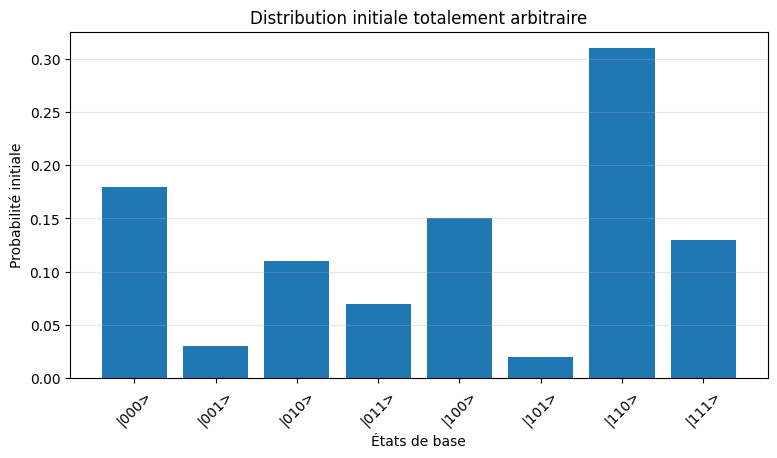

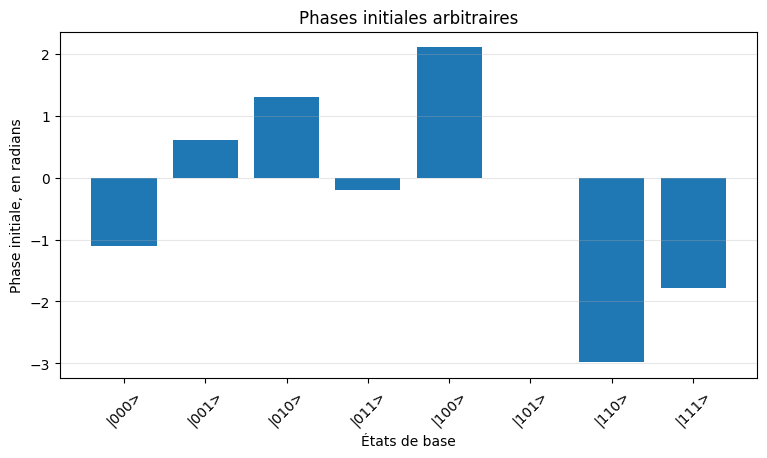

In [5]:

labels = [f"|{basis_label(i, n)}>" for i in range(N)]
probs0 = np.abs(psi0)**2
phases0 = np.angle(psi0)

plt.figure(figsize=(9, 4.5))
plt.bar(labels, probs0)
plt.xlabel("États de base")
plt.ylabel("Probabilité initiale")
plt.title("Distribution initiale totalement arbitraire")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4.5))
plt.bar(labels, phases0)
plt.xlabel("États de base")
plt.ylabel("Phase initiale, en radians")
plt.title("Phases initiales arbitraires")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()



## 4. Construction de $|\eta\rangle$, de $U$, puis de la phase adaptée

On extrait la composante non marquée de $|\psi_0\rangle$ :

$$
|\eta\rangle
=
\frac{(I-|\tau\rangle\langle\tau|)|\psi_0\rangle}
{\|(I-|\tau\rangle\langle\tau|)|\psi_0\rangle\|}.
$$

Ensuite on construit un unitaire $U$ dont la première colonne est

$$
U|0\rangle=\sin(\beta)|\tau\rangle+\cos(\beta)|\eta\rangle.
$$

Ici on prend $\sin(\beta)=\frac{1}{\sqrt{N}}$ comme dans le cas Grover usuel, afin de garder un angle $\beta$ comparable.


In [6]:

ket_tau = np.zeros(N, dtype=complex)
ket_tau[marked] = 1.0

non_marked_component = psi0.copy()
non_marked_component[marked] = 0.0

theta0 = np.arcsin(abs(psi0[marked]))
delta = 0.0  # les phases sont absorbées dans |eta>

eta = non_marked_component / np.linalg.norm(non_marked_component)

beta = np.arcsin(1 / np.sqrt(N))
u0 = np.sin(beta) * ket_tau + np.cos(beta) * eta

U_adapted = unitary_with_first_column(u0)

print("Vérifications numériques :")
print(f"||U†U - I|| = {np.linalg.norm(U_adapted.conj().T @ U_adapted - np.eye(N)):.3e}")
print(f"||U|0> - u0|| = {np.linalg.norm(U_adapted[:, 0] - u0):.3e}")
print()
print(f"theta0 = {theta0:.12f} rad")
print(f"delta  = {delta:.12f} rad")
print(f"beta   = {beta:.12f} rad")


Vérifications numériques :
||U†U - I|| = 1.396e-15
||U|0> - u0|| = 1.846e-16

theta0 = 0.141897054604 rad
delta  = 0.000000000000 rad
beta   = 0.361367123907 rad


In [7]:

theta = np.pi / 2
phi_matched = phase_matching_phi(beta, theta0, delta, theta)

lhs = np.tan(theta / 2) * (
    np.cos(2 * beta)
    + np.tan(theta0) * np.cos(delta) * np.sin(2 * beta)
)

rhs = np.tan(phi_matched / 2) * (
    1
    - np.tan(theta0) * np.sin(delta) * np.sin(2 * beta) * np.tan(theta / 2)
)

print(f"theta choisi = {theta:.12f} rad")
print(f"phi adapté   = {phi_matched:.12f} rad")
print()
print("Vérification de la condition de phase :")
print(f"Côté gauche = {lhs:.15f}")
print(f"Côté droit  = {rhs:.15f}")
print(f"Différence  = {abs(lhs - rhs):.3e}")


theta choisi = 1.570796326795 rad
phi adapté   = 1.402574335376 rad

Vérification de la condition de phase :
Côté gauche = 0.844491118252307
Côté droit  = 0.844491118252307
Différence  = 1.110e-16



## 5. Comparaison avec Grover standard

### A. Algorithme avec $U$ adapté et phase adaptée

$$
Q_{\mathrm{adapted}}
=
-U_{\mathrm{adapted}} I_\gamma(\theta)
U_{\mathrm{adapted}}^\dagger
I_\tau(\phi_{\mathrm{matched}}).
$$

### B. Grover standard

$$
Q_{\mathrm{std}}
=
-H^{\otimes n} I_\gamma(\pi)
H^{\otimes n}
I_\tau(\pi).
$$

Les deux algorithmes partent exactement du même état initial arbitraire $|\psi_0\rangle$


In [8]:

max_iter = 30

Q_adapted = grover_engine(n, marked, theta, phi_matched, U_adapted)
Q_standard = grover_engine(n, marked, np.pi, np.pi, hadamard(n))

p_adapted = success_probabilities(Q_adapted, psi0, marked, max_iter)
p_standard = success_probabilities(Q_standard, psi0, marked, max_iter)

j_best_adapted = int(np.argmax(p_adapted))
j_best_standard = int(np.argmax(p_standard))

print("Meilleure probabilité observée entre 0 et", max_iter, "itérations")
print("-" * 75)
print(f"Algo adapté    : j = {j_best_adapted:2d}, P_succès = {p_adapted[j_best_adapted]:.12f}")
print(f"Grover standard: j = {j_best_standard:2d}, P_succès = {p_standard[j_best_standard]:.12f}")
print()
print(f"Gain absolu = {p_adapted[j_best_adapted] - p_standard[j_best_standard]:.12f}")
print(f"Gain relatif = {p_adapted[j_best_adapted] / p_standard[j_best_standard]:.3f}x")


Meilleure probabilité observée entre 0 et 30 itérations
---------------------------------------------------------------------------
Algo adapté    : j =  3, P_succès = 0.999903070344
Grover standard: j = 30, P_succès = 0.022861360786

Gain absolu = 0.977041709558
Gain relatif = 43.738x


In [9]:

print("Table des probabilités :")
print("j | algo adapté | Grover standard | gain")
print("--|-------------|-----------------|-------------")
for j in range(max_iter + 1):
    print(
        f"{j:2d}| "
        f"{p_adapted[j]:.12f} | "
        f"{p_standard[j]:.12f} | "
        f"{p_adapted[j] - p_standard[j]:+.12f}"
    )


Table des probabilités :
j | algo adapté | Grover standard | gain
--|-------------|-----------------|-------------
 0| 0.020000000000 | 0.020000000000 | +0.000000000000
 1| 0.309665981829 | 0.006013551254 | +0.303652430575
 2| 0.773069912047 | 0.003158861198 | +0.769911050848
 3| 0.999903070344 | 0.016431637431 | +0.983471432913
 4| 0.789322052435 | 0.022604521544 | +0.766717530890
 5| 0.327780235913 | 0.010874966340 | +0.316905269573
 6| 0.023937581901 | 0.001769693426 | +0.022167888475
 7| 0.146823510334 | 0.011222930401 | +0.135600579933
 8| 0.587631934878 | 0.022691512559 | +0.564940422319
 9| 0.956060726479 | 0.016105421124 | +0.939955305355
10| 0.925894382527 | 0.002990316106 | +0.922904066421
11| 0.523842892249 | 0.006297631288 | +0.517545260962
12| 0.105892085106 | 0.020239565100 | +0.085652520006
13| 0.042105419020 | 0.020417733372 | +0.021687685648
14| 0.388961105823 | 0.006520341628 | +0.382440764195
15| 0.839344976420 | 0.002867825420 | +0.836477151000
16| 0.994476576995 | 


## 6. Graphiques de comparaison


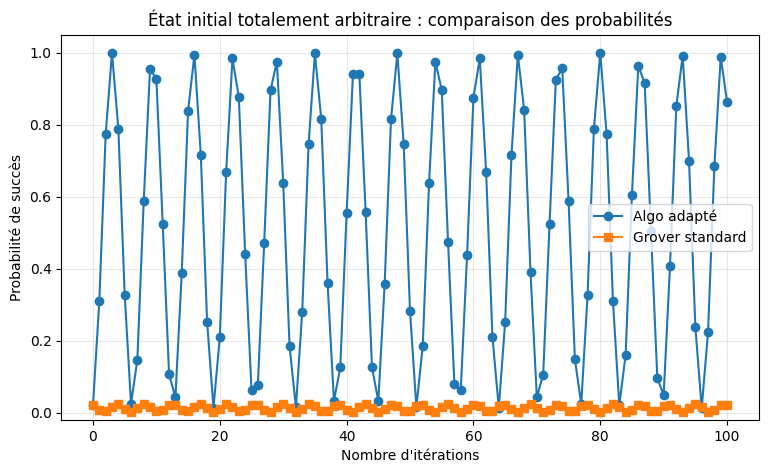

In [10]:

plt.figure(figsize=(9, 5))
plt.plot(range(max_iter + 1), p_adapted, marker="o", label="Algo adapté")
plt.plot(range(max_iter + 1), p_standard, marker="s", label="Grover standard")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Probabilité de succès")
plt.title("État initial totalement arbitraire : comparaison des probabilités")
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


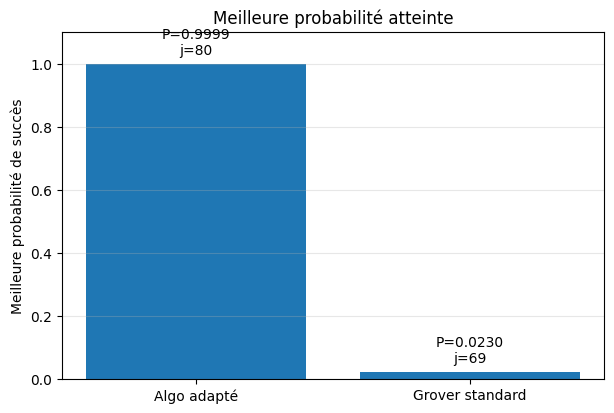

In [11]:

methods = ["Algo adapté", "Grover standard"]
best_probs = [p_adapted[j_best_adapted], p_standard[j_best_standard]]
best_iters = [j_best_adapted, j_best_standard]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(methods, best_probs)

for bar, prob, j in zip(bars, best_probs, best_iters):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        prob + 0.02,
        f"P={prob:.4f}\nj={j}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Meilleure probabilité de succès")
plt.title("Meilleure probabilité atteinte")
plt.ylim(0, 1.1)
plt.grid(axis="y", alpha=0.3)
plt.show()


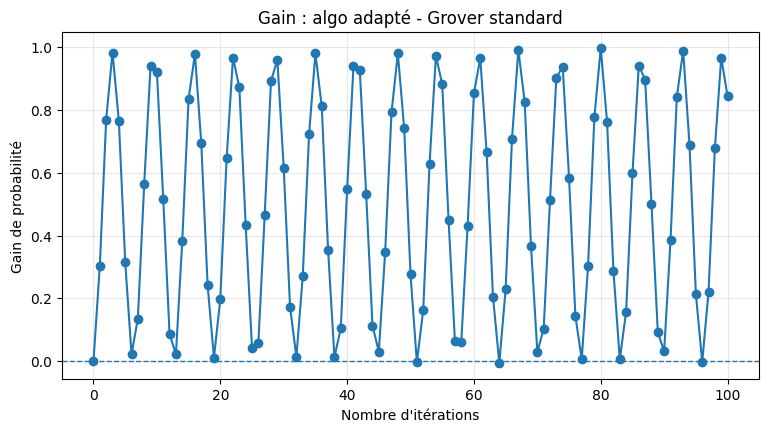

In [12]:

gain = p_adapted - p_standard

plt.figure(figsize=(9, 4.5))
plt.plot(range(max_iter + 1), gain, marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Nombre d'itérations")
plt.ylabel("Gain de probabilité")
plt.title("Gain : algo adapté - Grover standard")
plt.grid(True, alpha=0.3)
plt.show()


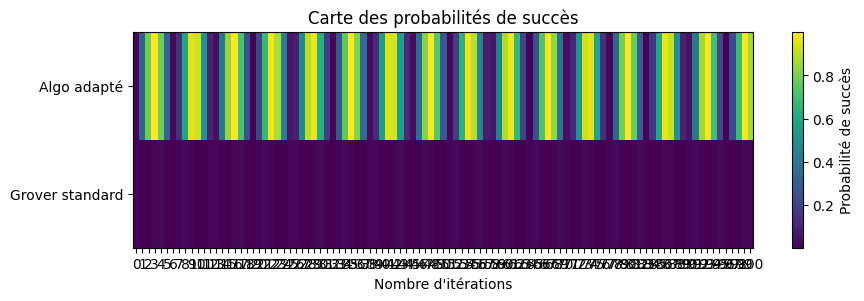

In [13]:

data = np.vstack([p_adapted, p_standard])

plt.figure(figsize=(10, 2.8))
plt.imshow(data, aspect="auto")
plt.colorbar(label="Probabilité de succès")
plt.yticks([0, 1], ["Algo adapté", "Grover standard"])
plt.xticks(range(max_iter + 1))
plt.xlabel("Nombre d'itérations")
plt.title("Carte des probabilités de succès")
plt.show()



## 7. Coût des phases vs gain en nombre d'itérations

L'amélioration de probabilité ne suffit pas à conclure que l'algorithme est globalement meilleur.

Il faut comparer :

$$
\text{gain en itérations}
\quad \text{vs} \quad
\text{coût de calcul et d'implémentation de } U,\theta,\phi.
$$

Ici, on distingue trois coûts :

1. **Coût classique de prétraitement** : calculer $\beta$, $\theta_0$, $\delta$, puis $\phi$
2. **Coût quantique par itération** : appliquer $Q=-UI_\gamma U^\dagger I_\tau$
3. **Coût de synthèse de circuit** : implémenter concrètement $U$,$U^\dagger$, $I_\gamma$, $I_\tau$

Dans un petit exemple à 3 qubits, ces coûts sont négligeables. Mais asymptotiquement, construire un $U$ adapté à un état arbitraire peut être beaucoup plus coûteux que quelques itérations de Grover standard.



### 7.1 Coût classique du calcul des phases

Dans le cas à une solution marquée, on utilise :

$$
\theta_0=\arcsin(|\langle \tau|\psi_0\rangle|),
$$

$$
\beta=\arcsin(|\langle \tau|U|0\rangle|),
$$

puis

$$
\phi
=
2\arctan
\left(
\frac{
\tan(\theta/2)
\left[
\cos(2\beta)+\tan(\theta_0)\cos(\delta)\sin(2\beta)
\right]
}{
1-\tan(\theta_0)\sin(\delta)\sin(2\beta)\tan(\theta/2)
}
\right).
$$

Dans notre implémentation, ce calcul est de coût constant une fois $\theta_0,\beta,\delta$ connus.

En revanche, si l'état initial est donné par une liste complète de \(N\) amplitudes, extraire et normaliser la composante non marquée coûte typiquement $O(N)$ opérations classiques.


In [14]:

# Estimation simple du coût classique de prétraitement

classical_cost = {
    "lecture des N amplitudes": N,
    "extraction amplitude marquée": 1,
    "norme composante non marquée": N - 1,
    "calcul theta0, beta, phi": 1,
}

print("Estimation du coût classique de prétraitement, en nombre d'opérations abstraites :")
for name, cost in classical_cost.items():
    print(f"- {name:35s}: {cost}")

total_classical_cost = sum(classical_cost.values())
print("-" * 55)
print(f"Total indicatif : {total_classical_cost} opérations abstraites")


Estimation du coût classique de prétraitement, en nombre d'opérations abstraites :
- lecture des N amplitudes           : 8
- extraction amplitude marquée       : 1
- norme composante non marquée       : 7
- calcul theta0, beta, phi           : 1
-------------------------------------------------------
Total indicatif : 17 opérations abstraites



### 7.2 Coût quantique d'une itération

Pour une itération adaptée :

$$
Q_{\mathrm{adapted}}
=
-U_{\mathrm{adapted}} I_\gamma(\theta)
U_{\mathrm{adapted}}^\dagger
I_\tau(\phi).
$$

Elle nécessite donc :

- une application de $U_{\mathrm{adapted}}$,
- une application de $U_{\mathrm{adapted}}^\dagger$,
- une phase sur $|0\rangle$,
- une phase sur $|\tau\rangle$

Pour Grover standard :

$$
Q_{\mathrm{std}}
=
-H^{\otimes n}I_\gamma(\pi)H^{\otimes n}I_\tau(\pi).
$$

Le coût par itération est souvent beaucoup plus faible, car $H^{\otimes n}$ coûte seulement $n$ portes de Hadamard.

Pour un $U_{\mathrm{adapted}}$ arbitraire sur $n$ qubits, la synthèse exacte peut demander un nombre de portes qui croît comme $O(4^n)$ dans le cas général d'un unitaire dense.


In [ ]:

# Modèle de coût simplifié
# Ces coûts ne sont pas des comptages exacts de portes, mais une estimation qualitative utile.

cost_H_layer = n                       # H^{otimes n}
cost_oracle_phase = 1                  # phase sur l'état marqué
cost_zero_phase = 1                    # phase sur |0...0>

# Pour un unitaire arbitraire dense sur n qubits, on met un coût indicatif exponentiel.
# Ici on prend 4^n comme ordre de grandeur.
cost_U_adapted = 4**n

cost_per_iter_standard = 2 * cost_H_layer + cost_zero_phase + cost_oracle_phase
cost_per_iter_adapted = 2 * cost_U_adapted + cost_zero_phase + cost_oracle_phase

print("Modèle de coût par itération :")
print(f"Coût H^{n}                    : {cost_H_layer}")
print(f"Coût U_adapted arbitraire      : {cost_U_adapted}")
print()
print(f"Coût par itération Grover standard : {cost_per_iter_standard}")
print(f"Coût par itération algo adapté     : {cost_per_iter_adapted}")
print(f"Ratio coût adapté / standard       : {cost_per_iter_adapted / cost_per_iter_standard:.2f}x")


Modèle de coût par itération :
Coût H^3                    : 3
Coût U_adapted arbitraire      : 64

Coût par itération Grover standard : 8
Coût par itération algo adapté     : 130
Ratio coût adapté / standard       : 16.25x



### 7.3 Gain brut en nombre d'itérations

On peut comparer le nombre d'itérations nécessaires pour atteindre une probabilité cible.

Par exemple, si je fixe $P_{\mathrm{cible}}=0.9$

On cherche le premier \(j\) tel que

$$
P_{\mathrm{succès}}(j)\geq P_{\mathrm{cible}}.
$$


In [16]:

def first_iteration_above_threshold(probs: np.ndarray, threshold: float):
    idx = np.where(probs >= threshold)[0]
    if len(idx) == 0:
        return None
    return int(idx[0])

target_probability = 0.90

j_target_adapted = first_iteration_above_threshold(p_adapted, target_probability)
j_target_standard = first_iteration_above_threshold(p_standard, target_probability)

print(f"Probabilité cible : {target_probability}")
print()
print(f"Algo adapté     : premier j atteignant la cible = {j_target_adapted}")
print(f"Grover standard : premier j atteignant la cible = {j_target_standard}")

if j_target_adapted is not None and j_target_standard is not None:
    iteration_gain = j_target_standard - j_target_adapted
    print(f"Gain brut en itérations = {iteration_gain}")
elif j_target_adapted is not None and j_target_standard is None:
    print("Grover standard n'atteint pas la cible dans la fenêtre simulée.")
    print("Le gain en itérations est donc au moins supérieur à la fenêtre testée.")
else:
    print("Aucun des deux algorithmes n'atteint la cible dans la fenêtre simulée.")


Probabilité cible : 0.9

Algo adapté     : premier j atteignant la cible = 3
Grover standard : premier j atteignant la cible = None
Grover standard n'atteint pas la cible dans la fenêtre simulée.
Le gain en itérations est donc au moins supérieur à la fenêtre testée.



### 7.4 Coût total estimé

Le coût total peut être estimé par

$$
C_{\mathrm{total}}
=
C_{\mathrm{prétraitement}}
+
j \times C_{\mathrm{itération}}.
$$

Cette formule montre le compromis :

- si $U_{\mathrm{adapted}}$ est facile à implémenter, le gain en itérations peut être réellement avantageux ;
- si $U_{\mathrm{adapted}}$ est un unitaire dense arbitraire, son coût peut annuler l'avantage ;
- l'algorithme est donc surtout intéressant quand les phases et $U$ ont une structure exploitable.


In [17]:

# Comparaison de coût total pour une probabilité cible.
# Si Grover standard n'atteint pas la cible, on compare avec son meilleur j observé.

if j_target_adapted is None:
    j_cost_adapted = j_best_adapted
    note_adapted = "meilleur j observé"
else:
    j_cost_adapted = j_target_adapted
    note_adapted = "premier j atteignant la cible"

if j_target_standard is None:
    j_cost_standard = j_best_standard
    note_standard = "meilleur j observé, cible non atteinte"
else:
    j_cost_standard = j_target_standard
    note_standard = "premier j atteignant la cible"

total_cost_adapted = total_classical_cost + j_cost_adapted * cost_per_iter_adapted
total_cost_standard = j_cost_standard * cost_per_iter_standard

print("Comparaison de coût total estimé")
print("-" * 70)
print(f"Algo adapté     : j = {j_cost_adapted:2d} ({note_adapted})")
print(f"                 coût total estimé = {total_cost_adapted}")
print()
print(f"Grover standard : j = {j_cost_standard:2d} ({note_standard})")
print(f"                 coût total estimé = {total_cost_standard}")
print()
print(f"Ratio coût adapté / standard = {total_cost_adapted / total_cost_standard:.2f}x")


Comparaison de coût total estimé
----------------------------------------------------------------------
Algo adapté     : j =  3 (premier j atteignant la cible)
                 coût total estimé = 407

Grover standard : j = 69 (meilleur j observé, cible non atteinte)
                 coût total estimé = 552

Ratio coût adapté / standard = 0.74x


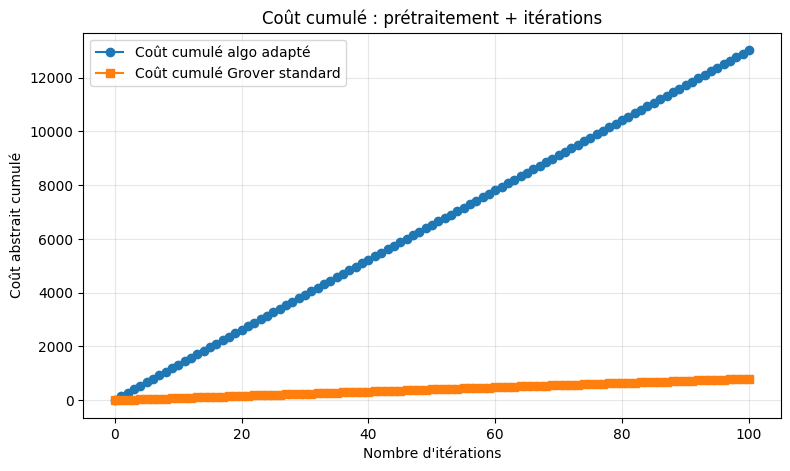

In [18]:

# Graphique : coût total cumulé en fonction du nombre d'itérations

iterations = np.arange(max_iter + 1)

cost_curve_adapted = total_classical_cost + iterations * cost_per_iter_adapted
cost_curve_standard = iterations * cost_per_iter_standard

plt.figure(figsize=(9, 5))
plt.plot(iterations, cost_curve_adapted, marker="o", label="Coût cumulé algo adapté")
plt.plot(iterations, cost_curve_standard, marker="s", label="Coût cumulé Grover standard")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Coût abstrait cumulé")
plt.title("Coût cumulé : prétraitement + itérations")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


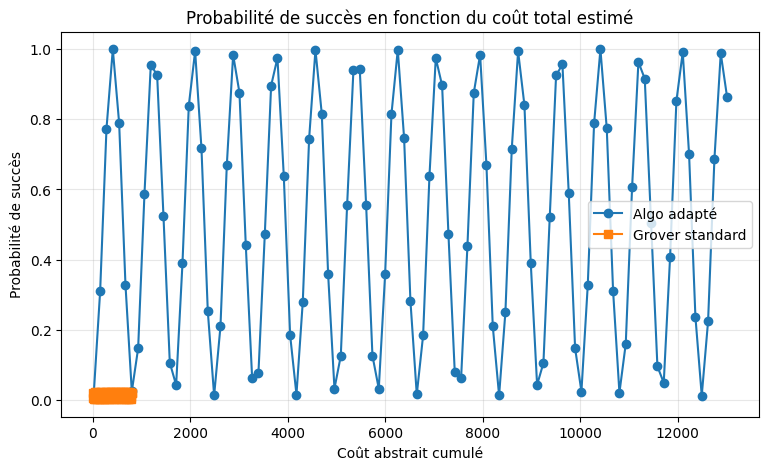

In [19]:

# Graphique : probabilité de succès en fonction du coût cumulé

plt.figure(figsize=(9, 5))
plt.plot(cost_curve_adapted, p_adapted, marker="o", label="Algo adapté")
plt.plot(cost_curve_standard, p_standard, marker="s", label="Grover standard")
plt.xlabel("Coût abstrait cumulé")
plt.ylabel("Probabilité de succès")
plt.title("Probabilité de succès en fonction du coût total estimé")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



### 7.5 Interprétation

Dans cet exemple, l'algorithme adapté gagne clairement en probabilité et en nombre d'itérations.

Mais si on compte le coût d'un $U_{\mathrm{adapted}}$ arbitraire dense, alors chaque itération adaptée peut être beaucoup plus chère qu'une itération de Grover standard.

L'algorithme à phases adaptées est avantageux en nombre d'itérations et en probabilité de succès, mais son avantage opérationnel réel dépend du coût de calcul et d'implémentation de $U$, $\theta$ et $\phi$

En pratique, l'algorithme est surtout intéressant si :

- $U$ possède une structure simple ;
- les phases $\theta,\phi$ sont faciles à synthétiser ;
- l'état initial arbitraire n'est pas fourni comme une liste sans structure de $N$ amplitudes ;
- le gain en itérations compense le surcoût de préparation et d'implémentation.



## 8. Conclusion

- les probabilités initiales sont toutes différentes ;
- les phases initiales sont arbitraires ;
- l'état marqué commence avec une faible probabilité ;
- l'algorithme adapté construit $U$ pour que la dynamique pertinente reste dans le sous-espace $|\tau\rangle,|\eta\rangle$ ;
- la phase $\phi$ est ensuite choisie par la condition générale de phase matching.

--> L'algorithme adapté atteint une probabilité de succès proche de 1, alors que Grover standard reste très faible sur le même état initial arbitraire.
